In [1]:
import sys
#print(sys.executable)

In [2]:
#  Imports 
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns

#load the dataset in data/train.csv
data = pd.read_csv('data/train.csv')

In [3]:
#load the dataset in data/train.csv
train_raw = pd.read_csv('data/train.csv')

Data Visualization

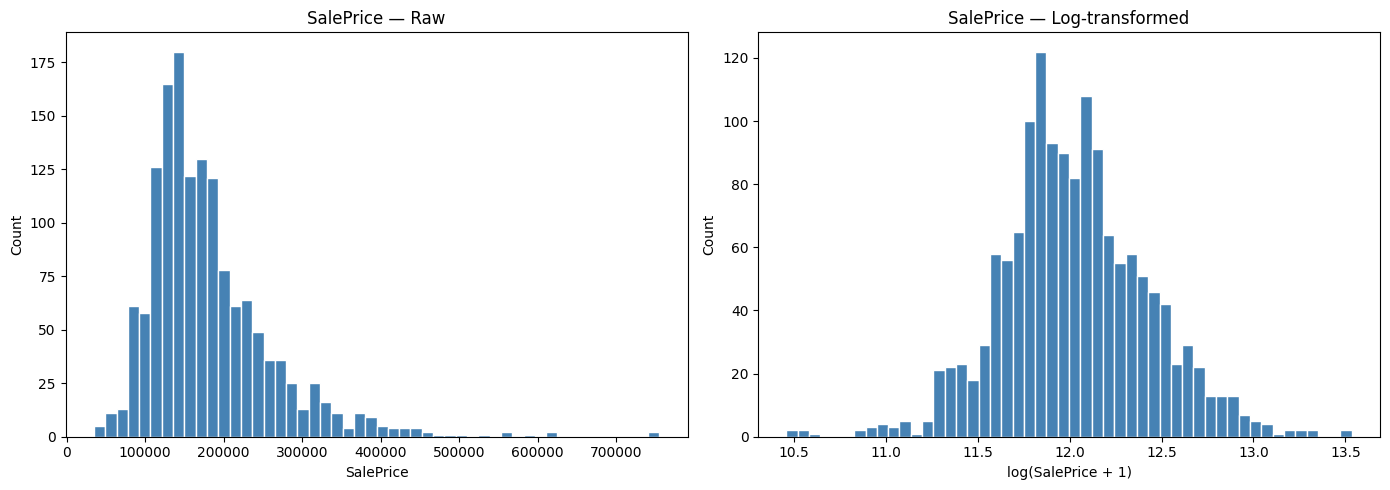

Skewness raw: 1.883  |  log-transformed: 0.121


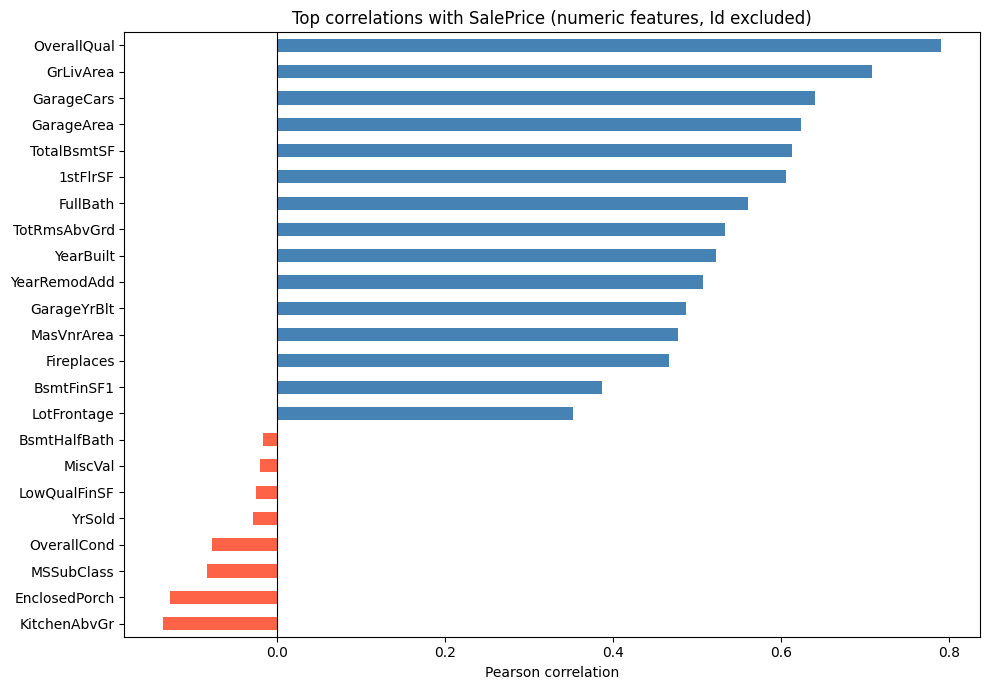

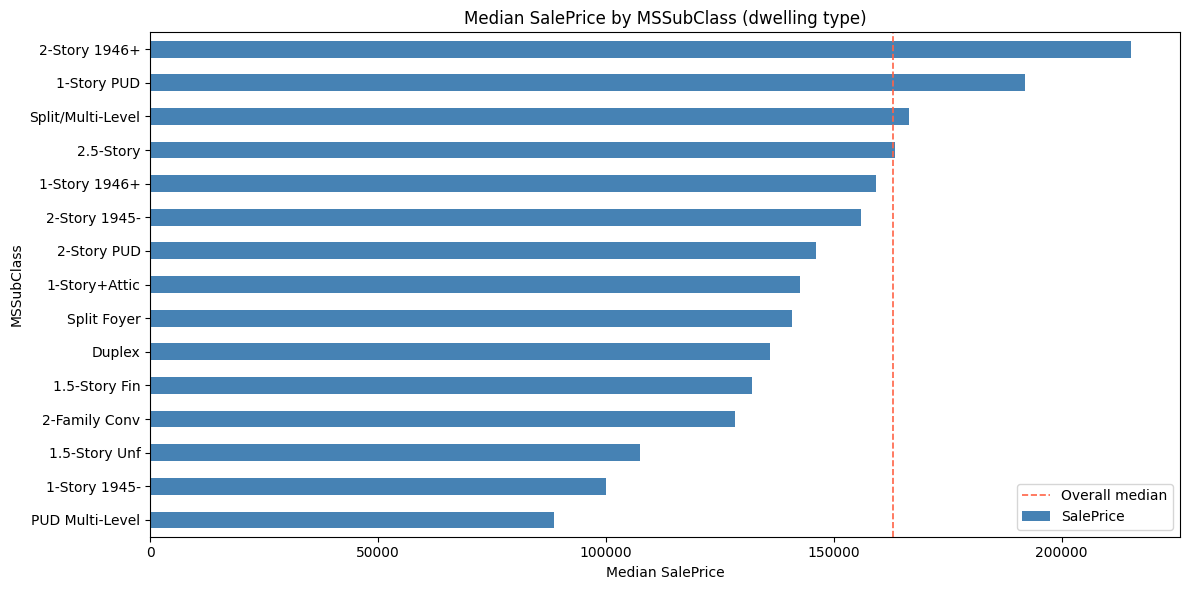

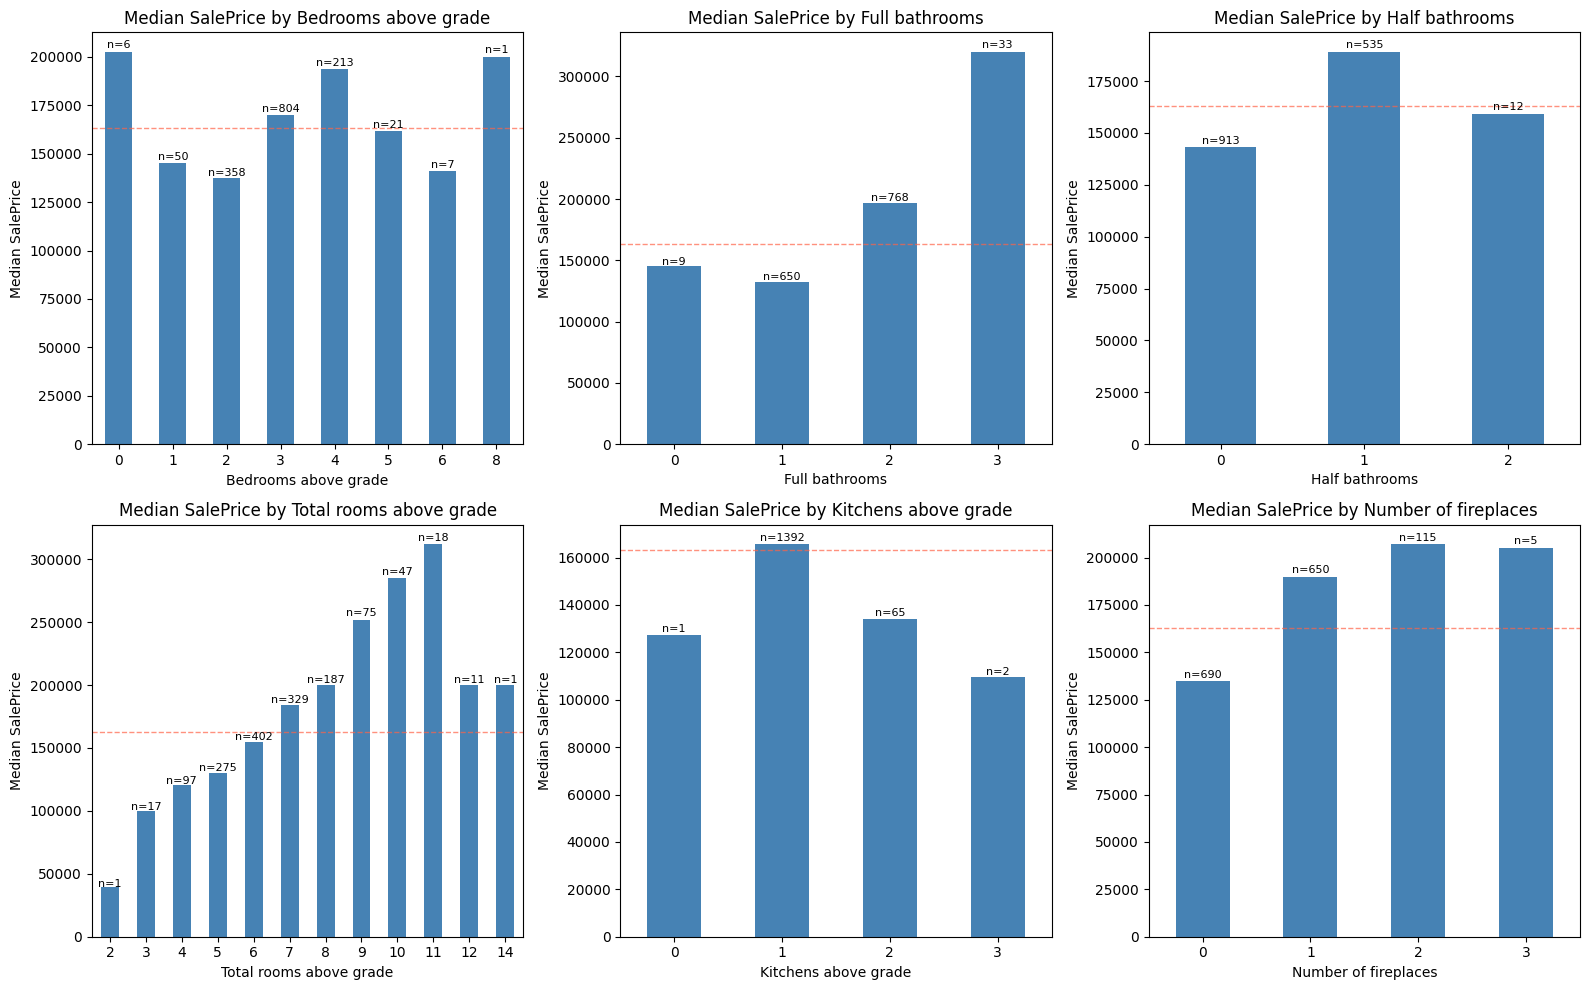

In [4]:

# ── 1. SalePrice distribution: raw vs log-transformed ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_raw['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice — Raw')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(train_raw['SalePrice']), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('SalePrice — Log-transformed')
axes[1].set_xlabel('log(SalePrice + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

skew_raw = train_raw['SalePrice'].skew()
skew_log = np.log1p(train_raw['SalePrice']).skew()
print(f"Skewness raw: {skew_raw:.3f}  |  log-transformed: {skew_log:.3f}")

# ── 2. Top numeric correlations with SalePrice ────────────────────────────────
exclude = ['SalePrice', 'Id']
numeric_cols = [c for c in train_raw.select_dtypes(include=[np.number]).columns if c not in exclude]
corr = train_raw[numeric_cols + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').sort_values()

top_corr = pd.concat([corr.head(8), corr.tail(15)])

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['tomato' if v < 0 else 'steelblue' for v in top_corr.values]
top_corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top correlations with SalePrice (numeric features, Id excluded)')
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

# ── 2b. MSSubClass — median SalePrice by dwelling type ────────────────────────
mss_labels = {
    20: '1-Story 1946+',    30: '1-Story 1945-',    40: '1-Story+Attic',
    45: '1.5-Story Unf',   50: '1.5-Story Fin',    60: '2-Story 1946+',
    70: '2-Story 1945-',   75: '2.5-Story',         80: 'Split/Multi-Level',
    85: 'Split Foyer',     90: 'Duplex',           120: '1-Story PUD',
   150: '1.5-Story PUD',  160: '2-Story PUD',      180: 'PUD Multi-Level',
   190: '2-Family Conv'
}
mss = (train_raw.groupby('MSSubClass')['SalePrice']
       .median()
       .rename(index=mss_labels)
       .sort_values())

fig, ax = plt.subplots(figsize=(12, 6))
mss.plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(train_raw['SalePrice'].median(), color='tomato',
           linestyle='--', linewidth=1.2, label='Overall median')
ax.set_title('Median SalePrice by MSSubClass (dwelling type)')
ax.set_xlabel('Median SalePrice')
ax.legend()
plt.tight_layout()
plt.show()

# ── 2c. Building characteristics vs SalePrice ─────────────────────────────────
char_features = [
    ('BedroomAbvGr', 'Bedrooms above grade'),
    ('FullBath',     'Full bathrooms'),
    ('HalfBath',     'Half bathrooms'),
    ('TotRmsAbvGrd', 'Total rooms above grade'),
    ('KitchenAbvGr', 'Kitchens above grade'),
    ('Fireplaces',   'Number of fireplaces'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(char_features):
    medians = train_raw.groupby(col)['SalePrice'].median()
    counts  = train_raw.groupby(col)['SalePrice'].count()
    medians.plot(kind='bar', ax=axes[i], color='steelblue', rot=0)
    # annotate each bar with sample count
    for j, (val, cnt) in enumerate(zip(medians, counts)):
        axes[i].text(j, val * 1.01, f'n={cnt}', ha='center', fontsize=8)
    axes[i].set_title(f'Median SalePrice by {label}')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Median SalePrice')
    axes[i].axhline(train_raw['SalePrice'].median(), color='tomato',
                    linestyle='--', linewidth=1, alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
# Log-transform SalePrice: aligns training objective with RMSLE competition metric
# and corrects right skew (raw skew ~1.88 → ~0.12 after transform).
# Invert predictions at submission time with np.expm1().
train_raw['SalePrice'] = np.log1p(train_raw['SalePrice'])

In [5]:
train_raw.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


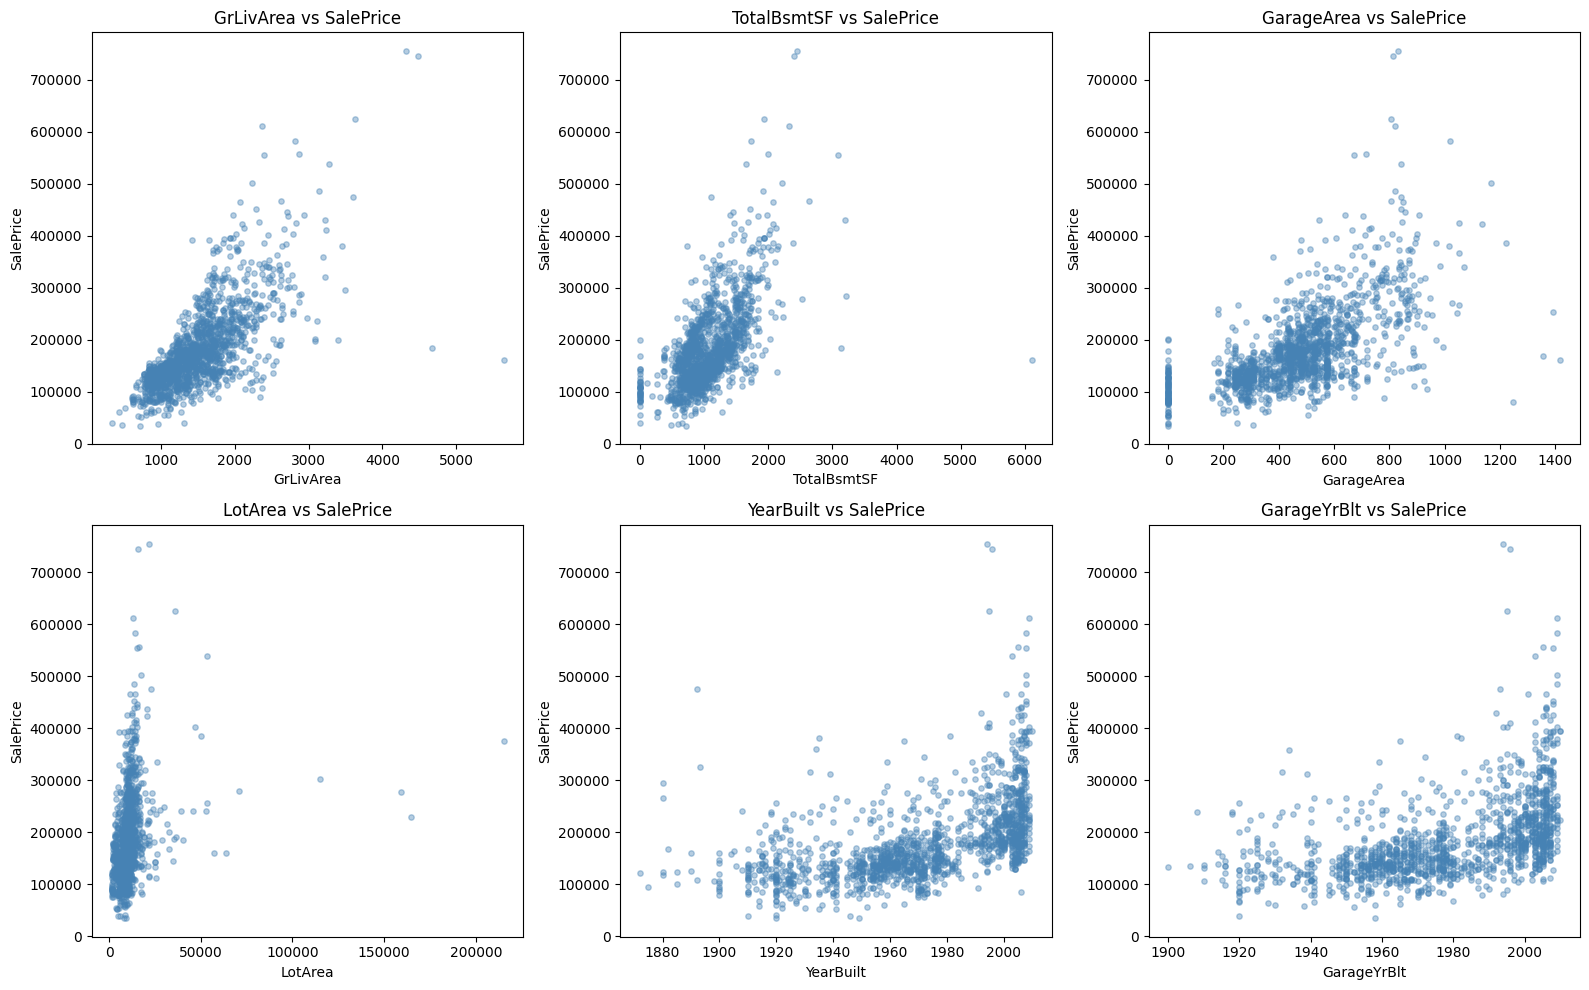

In [6]:
# ── 3. Key numeric features vs SalePrice (scatter) ───────────────────────────
# GarageYrBlt used here (GarageAge is derived later during feature engineering)
scatter_features = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', 'LotArea', 'YearBuilt', 'GarageYrBlt']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(scatter_features):
    axes[i].scatter(train_raw[feat], train_raw['SalePrice'],
                    alpha=0.4, s=15, color='steelblue')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{feat} vs SalePrice')

plt.tight_layout()
plt.show()


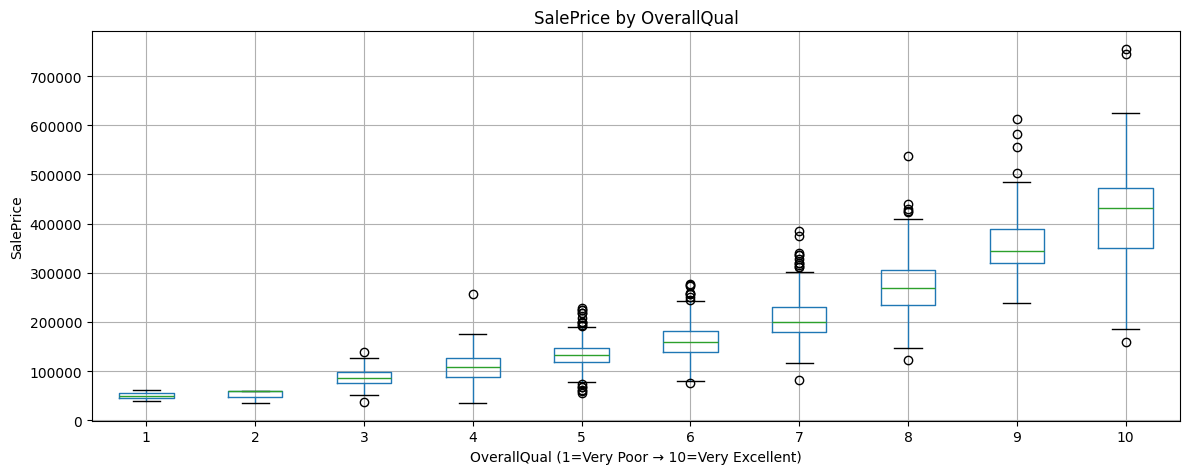

In [7]:
# ── 4. SalePrice by OverallQual (boxplot) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
train_raw.boxplot(column='SalePrice', by='OverallQual', ax=ax)
ax.set_title('SalePrice by OverallQual')
ax.set_xlabel('OverallQual (1=Very Poor → 10=Very Excellent)')
ax.set_ylabel('SalePrice')
plt.suptitle('')  # suppress pandas auto-title
plt.tight_layout()
plt.show()


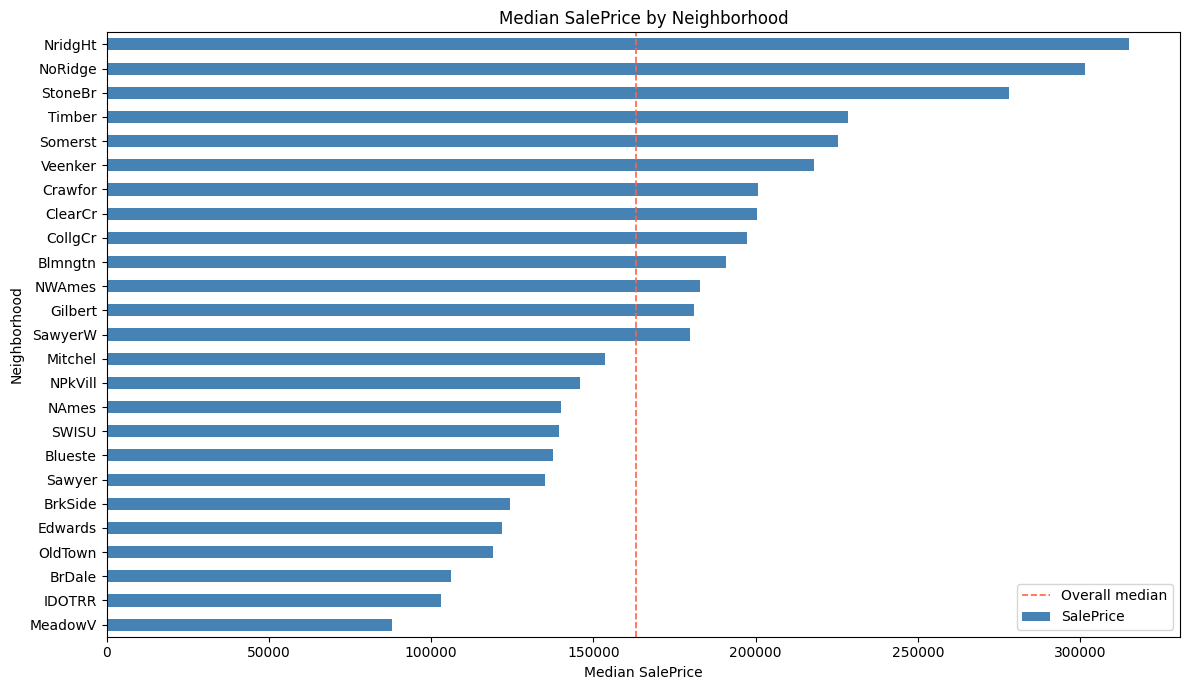

In [8]:
# ── 5. Median SalePrice by Neighborhood ──────────────────────────────────────
nbhd = (train_raw.groupby('Neighborhood')['SalePrice']
        .median()
        .sort_values())

fig, ax = plt.subplots(figsize=(12, 7))
nbhd.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Median SalePrice by Neighborhood')
ax.set_xlabel('Median SalePrice')
ax.axvline(train_raw['SalePrice'].median(), color='tomato',
           linestyle='--', linewidth=1.2, label='Overall median')
ax.legend()
plt.tight_layout()
plt.show()


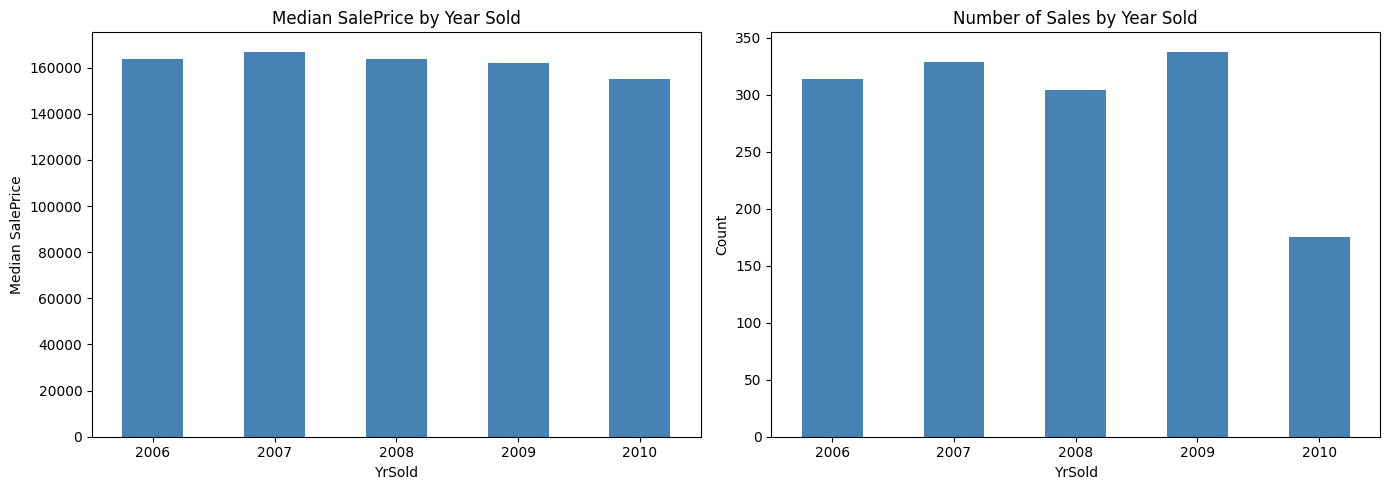

In [9]:
# ── 6. SalePrice by YrSold — shows 2008 financial crisis effect ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yr_stats = train_raw.groupby('YrSold')['SalePrice'].agg(['median', 'count'])
yr_stats['median'].plot(kind='bar', ax=axes[0], color='steelblue', rot=0)
axes[0].set_title('Median SalePrice by Year Sold')
axes[0].set_xlabel('YrSold')
axes[0].set_ylabel('Median SalePrice')

yr_stats['count'].plot(kind='bar', ax=axes[1], color='steelblue', rot=0)
axes[1].set_title('Number of Sales by Year Sold')
axes[1].set_xlabel('YrSold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


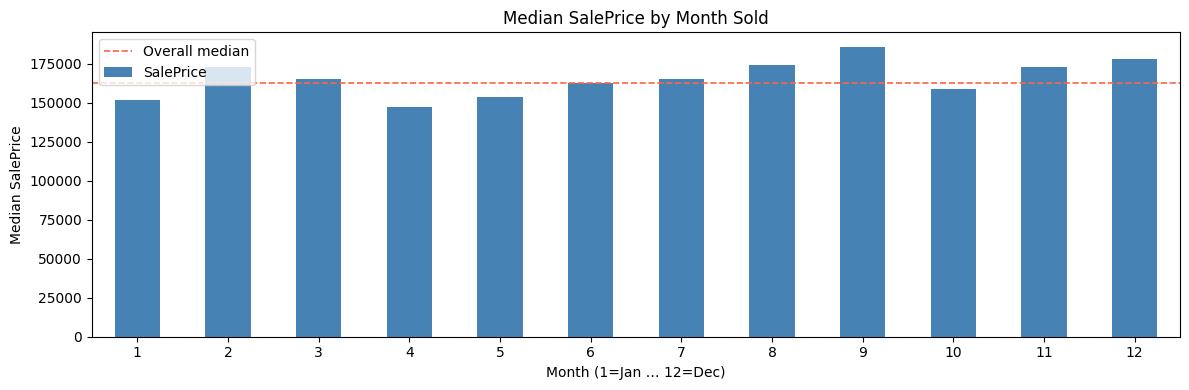

In [10]:
# ── 7. SalePrice by MoSold — seasonality ─────────────────────────────────────
mo_median = train_raw.groupby('MoSold')['SalePrice'].median()

fig, ax = plt.subplots(figsize=(12, 4))
mo_median.plot(kind='bar', ax=ax, color='steelblue', rot=0)
ax.set_title('Median SalePrice by Month Sold')
ax.set_xlabel('Month (1=Jan … 12=Dec)')
ax.set_ylabel('Median SalePrice')
ax.axhline(train_raw['SalePrice'].median(), color='tomato',
           linestyle='--', linewidth=1.2, label='Overall median')
ax.legend()
plt.tight_layout()
plt.show()


In [11]:
train_raw['MSZoning'].value_counts()

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

In [12]:
# LotFrontage imputation via frontage_ratio = LotFrontage / sqrt(LotArea)
# Strategy: median ratio per (Neighborhood, LotConfig) → Neighborhood → global fallback

known = train_raw['LotFrontage'].notna()

# Compute ratio on observed rows
train_raw['_frontage_ratio'] = np.where(
    known,
    train_raw['LotFrontage'] / np.sqrt(train_raw['LotArea']),
    np.nan
)

# Fit median ratios on training data (to be reused on test set later)
ratio_nbhd_cfg = (
    train_raw[known]
    .groupby(['Neighborhood', 'LotConfig'])['_frontage_ratio']
    .median()
)
ratio_nbhd = (
    train_raw[known]
    .groupby('Neighborhood')['_frontage_ratio']
    .median()
)
ratio_global = train_raw.loc[known, '_frontage_ratio'].median()

def impute_frontage(row):
    if pd.notna(row['LotFrontage']):
        return row['LotFrontage']
    ratio = ratio_nbhd_cfg.get(
        (row['Neighborhood'], row['LotConfig']),
        ratio_nbhd.get(row['Neighborhood'], ratio_global)
    )
    return ratio * np.sqrt(row['LotArea'])

train_raw['LotFrontage'] = train_raw.apply(impute_frontage, axis=1)
train_raw.drop(columns=['_frontage_ratio'], inplace=True)

missing_after = train_raw['LotFrontage'].isna().sum()
print(f"Missing LotFrontage after imputation: {missing_after}")
print(f"\nLotFrontage stats after imputation:\n{train_raw['LotFrontage'].describe().round(2)}")


Missing LotFrontage after imputation: 0

LotFrontage stats after imputation:
count    1460.00
mean       70.45
std        25.14
min        21.00
25%        58.00
50%        70.00
75%        81.00
max       313.00
Name: LotFrontage, dtype: float64


In [13]:
import pickle, os

# Save fitted imputer artifacts so the test notebook can apply the same ratios
# without refitting on test data.
os.makedirs('models', exist_ok=True)

lot_frontage_imputer = {
    'ratio_nbhd_cfg': ratio_nbhd_cfg,   # Series keyed by (Neighborhood, LotConfig)
    'ratio_nbhd':     ratio_nbhd,        # Series keyed by Neighborhood
    'ratio_global':   ratio_global,      # scalar fallback
}

with open('models/lot_frontage_imputer.pkl', 'wb') as f:
    pickle.dump(lot_frontage_imputer, f)

print("Saved: models/lot_frontage_imputer.pkl")

# ── HOW TO LOAD IN THE TEST NOTEBOOK ─────────────────────────────────────────
# with open('models/lot_frontage_imputer.pkl', 'rb') as f:
#     imp = pickle.load(f)
# ratio_nbhd_cfg = imp['ratio_nbhd_cfg']
# ratio_nbhd     = imp['ratio_nbhd']
# ratio_global   = imp['ratio_global']
# test['LotFrontage'] = test.apply(impute_frontage, axis=1)
# ─────────────────────────────────────────────────────────────────────────────


Saved: models/lot_frontage_imputer.pkl


In [14]:
train_raw["MasVnrType"].value_counts()

MasVnrType
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [15]:
# Investigate MasVnrType missingness vs MasVnrArea
mas_missing = train_raw['MasVnrType'].isna()
print(f"MasVnrType missing: {mas_missing.sum()} rows")
print(f"\nMasVnrArea for rows where MasVnrType is NaN:")
print(train_raw.loc[mas_missing, 'MasVnrArea'].value_counts(dropna=False))
print(f"\nMasVnrType value counts (including NaN):")
print(train_raw['MasVnrType'].value_counts(dropna=False))


MasVnrType missing: 872 rows

MasVnrArea for rows where MasVnrType is NaN:
MasVnrArea
0.0      859
NaN        8
1.0        2
288.0      1
344.0      1
312.0      1
Name: count, dtype: int64

MasVnrType value counts (including NaN):
MasVnrType
NaN        872
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64


In [16]:
# MasVnrType imputation
# NaN in this dataset means "None" (no veneer), NOT truly missing.
# Exception: 5 rows have NaN type but MasVnrArea > 0 — impute with most common type.

# 1. Fix MasVnrArea NaN → 0 first (8 rows missing both)
train_raw.loc[train_raw['MasVnrArea'].isna(), 'MasVnrArea'] = 0.0

# 2. NaN type + area == 0 → "None" (no veneer, data encoding artifact)
mask_none = train_raw['MasVnrType'].isna() & (train_raw['MasVnrArea'] == 0)
train_raw.loc[mask_none, 'MasVnrType'] = 'None'

# 3. NaN type + area > 0 → impute with most common type (BrkFace)
mask_has_area = train_raw['MasVnrType'].isna() & (train_raw['MasVnrArea'] > 0)
train_raw.loc[mask_has_area, 'MasVnrType'] = 'BrkFace'

print(f"MasVnrType missing after imputation: {train_raw['MasVnrType'].isna().sum()}")
print(f"MasVnrArea missing after imputation: {train_raw['MasVnrArea'].isna().sum()}")
print(f"\nMasVnrType value counts:\n{train_raw['MasVnrType'].value_counts()}")


MasVnrType missing after imputation: 0
MasVnrArea missing after imputation: 0

MasVnrType value counts:
MasVnrType
None       867
BrkFace    450
Stone      128
BrkCmn      15
Name: count, dtype: int64


In [17]:
train_raw["BsmtFinType1"].value_counts()


BsmtFinType1
Unf    430
GLQ    418
ALQ    220
BLQ    148
Rec    133
LwQ     74
Name: count, dtype: int64

In [18]:
train_raw["BsmtFinType2"].value_counts()

BsmtFinType2
Unf    1256
Rec      54
LwQ      46
BLQ      33
ALQ      19
GLQ      14
Name: count, dtype: int64

In [19]:
# Investigate all basement categorical columns
bsmt_cat = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']

print("--- Missing counts ---")
print(train_raw[bsmt_cat + ['BsmtFinSF1', 'TotalBsmtSF']].isna().sum())

# How many of the 5 categorical cols are NaN per row
n_missing = train_raw[bsmt_cat].isna().sum(axis=1)
print("\n--- # of basement cat cols missing per row ---")
print(n_missing.value_counts().sort_index())

# Rows with partial missingness (not all 5 NaN → real basement with a gap)
partial = train_raw[(n_missing > 0) & (n_missing < 5)]
print(f"\n--- Rows with PARTIAL missingness ({len(partial)} rows) ---")
print(partial[bsmt_cat + ['TotalBsmtSF']].to_string())


--- Missing counts ---
BsmtQual        37
BsmtCond        37
BsmtExposure    38
BsmtFinType1    37
BsmtFinType2    38
BsmtFinSF1       0
TotalBsmtSF      0
dtype: int64

--- # of basement cat cols missing per row ---
0    1421
1       2
5      37
Name: count, dtype: int64

--- Rows with PARTIAL missingness (2 rows) ---
    BsmtQual BsmtCond BsmtExposure BsmtFinType1 BsmtFinType2  TotalBsmtSF
332       Gd       TA           No          GLQ          NaN         3206
948       Gd       TA          NaN          Unf          Unf          936


In [20]:
# Basement categorical imputation (all 5 cols in one pass)
# NaN = "no basement" for rows where TotalBsmtSF == 0 (37 rows).
# Remaining isolated NaNs are real basements with one missing field → mode impute.

bsmt_cat = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']

# 1. No-basement rows: fill all 5 cols with 'NA'
no_bsmt = train_raw['TotalBsmtSF'] == 0
for col in bsmt_cat:
    train_raw.loc[no_bsmt, col] = 'NA'

# 2. Remaining isolated NaNs: real basement, missing one field → fill with mode
mode_defaults = {
    'BsmtExposure': 'No',   # row 948: basement exists, exposure unknown
    'BsmtFinType2': 'Unf',  # row 332: basement exists, second finish unknown
}
for col, fallback in mode_defaults.items():
    train_raw.loc[train_raw[col].isna(), col] = fallback

print("Missing after imputation:")
print(train_raw[bsmt_cat].isna().sum())


Missing after imputation:
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
dtype: int64


In [21]:

# Electrical: explore missing rows
elec_missing = train_raw['Electrical'].isna()
print(f"Electrical missing: {elec_missing.sum()} / {len(train_raw)} ({elec_missing.mean()*100:.1f}%)")
print(f"\n--- Electrical value counts (all rows) ---")
print(train_raw['Electrical'].value_counts(dropna=False))

profile_cols = [
    'YearBuilt', 'YearRemodAdd', 'Neighborhood', 'MSZoning',
    'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond',
    'Heating', 'HeatingQC', 'CentralAir',
    'GrLivArea', 'TotalBsmtSF', 'SalePrice'
]

print("\n--- Profile of rows with MISSING Electrical ---")
print(train_raw.loc[elec_missing, profile_cols].to_string())


Electrical missing: 1 / 1460 (0.1%)

--- Electrical value counts (all rows) ---
Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
NaN         1
Name: count, dtype: int64

--- Profile of rows with MISSING Electrical ---
      YearBuilt  YearRemodAdd Neighborhood MSZoning BldgType HouseStyle  OverallQual  OverallCond Heating HeatingQC CentralAir  GrLivArea  TotalBsmtSF  SalePrice
1379       2006          2007       Timber       RL     1Fam       SLvl            5            5    GasA        Gd          Y       1394          384     167500


In [22]:
# Electrical imputation
# 1 missing row: 2006 new-build with GasA heating and CentralAir → almost certainly SBrkr.
# Mode (SBrkr) accounts for 91.4% of all rows → safe mode imputation.

train_raw['Electrical'] = train_raw['Electrical'].fillna('SBrkr')

print(f"Electrical missing after imputation: {train_raw['Electrical'].isna().sum()}")
print(f"\nElectrical value counts:\n{train_raw['Electrical'].value_counts()}")


Electrical missing after imputation: 0

Electrical value counts:
Electrical
SBrkr    1335
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: count, dtype: int64


In [23]:
count_missing_garage = train_raw['GarageType'].isna().sum() 
print(f"GarageType missing: {count_missing_garage} rows")
count_missing_GarageYrBlt = train_raw['GarageYrBlt'].isna().sum()
print(f"GarageYrBlt missing: {count_missing_GarageYrBlt} rows")

GarageType missing: 81 rows
GarageYrBlt missing: 81 rows


In [24]:
# How many houses have a GarageYrBlt different from YearBuilt?
has_garage = train_raw['GarageYrBlt'].notna()

diff = train_raw.loc[has_garage, 'GarageYrBlt'] != train_raw.loc[has_garage, 'YearBuilt']
print(f"Houses WITH garage:              {has_garage.sum()}")
print(f"  GarageYrBlt == YearBuilt:      {(~diff).sum()}")
print(f"  GarageYrBlt != YearBuilt:      {diff.sum()}  ({diff.mean()*100:.1f}%)")

# Distribution of the gap (GarageYrBlt - YearBuilt) for houses where they differ
gap = train_raw.loc[has_garage & diff, 'GarageYrBlt'] - train_raw.loc[has_garage & diff, 'YearBuilt']
print(f"\nGap (GarageYrBlt - YearBuilt) for differing rows:")
print(gap.describe().round(1))
print(f"\nGap distribution (years added later):")
print(gap.value_counts().sort_index().head(20))


Houses WITH garage:              1379
  GarageYrBlt == YearBuilt:      1089
  GarageYrBlt != YearBuilt:      290  (21.0%)

Gap (GarageYrBlt - YearBuilt) for differing rows:
count    290.0
mean      26.4
std       27.6
min      -10.0
25%        2.0
50%       17.0
75%       45.0
max      123.0
dtype: float64

Gap distribution (years added later):
-10.0     1
-7.0      1
-6.0      1
-5.0      2
-2.0      1
-1.0      3
 1.0     52
 2.0     16
 3.0     10
 4.0      7
 5.0      4
 6.0      5
 7.0      5
 8.0      7
 9.0      3
 10.0     4
 11.0     3
 12.0     5
 13.0     3
 14.0     6
Name: count, dtype: int64


In [25]:
# GarageYrBlt → GarageAge
# No-garage rows (GarageYrBlt is NaN) → GarageAge = 0
# Garage rows → YrSold - GarageYrBlt, clipped to 0 (handles -10 data entry errors)

train_raw['GarageAge'] = np.where(
    train_raw['GarageYrBlt'].notna(),
    (train_raw['YrSold'] - train_raw['GarageYrBlt']).clip(lower=0),
    0
).astype(int)

train_raw.drop(columns=['GarageYrBlt'], inplace=True)

print(f"GarageYrBlt dropped. GarageAge created.")
print(f"\nGarageAge stats:\n{train_raw['GarageAge'].describe().round(1)}")
print(f"\nRows with GarageAge == 0 (no garage): {(train_raw['GarageAge'] == 0).sum()}")


GarageYrBlt dropped. GarageAge created.

GarageAge stats:
count    1460.0
mean       27.7
std        25.0
min         0.0
25%         4.0
50%        23.5
75%        46.0
max       107.0
Name: GarageAge, dtype: float64

Rows with GarageAge == 0 (no garage): 165


In [26]:
# MiscFeature: 96% missing (= "None"), remaining categories too sparse for meaningful dummies.
# MiscVal already encodes the dollar value (0 for no feature) → drop MiscFeature.

train_raw.drop(columns=['MiscFeature'], inplace=True)

print("MiscFeature dropped. MiscVal will carry the signal (0 = no misc feature).")
print(f"\nMiscVal stats:\n{train_raw['MiscVal'].describe().round(1)}")
print(f"\nNon-zero MiscVal rows: {(train_raw['MiscVal'] > 0).sum()}")


MiscFeature dropped. MiscVal will carry the signal (0 = no misc feature).

MiscVal stats:
count     1460.0
mean        43.5
std        496.1
min          0.0
25%          0.0
50%          0.0
75%          0.0
max      15500.0
Name: MiscVal, dtype: float64

Non-zero MiscVal rows: 52


In [27]:
# Feature Categorization and Encoding
data = train_raw.copy()

# Drop Id column
data = data.drop('Id', axis=1)

# ── Step 1: Fill "not applicable" NaN → 'NA' string for ordinal columns ──────
# Basement cols were already cleaned upstream.
# These cols still carry raw NaN for "no feature" rows.
na_as_none_ordinal = ['FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence']
for col in na_as_none_ordinal:
    data[col] = data[col].fillna('NA')

# Fill nominal "no feature" NaN → 'NA' so one-hot encoding is explicit
data['GarageType'] = data['GarageType'].fillna('NA')
data['Alley']      = data['Alley'].fillna('NA')

# ── Step 2: Cyclic encoding for MoSold (month is cyclic: Dec → Jan) ──────────
data['MoSold_sin'] = np.sin(2 * np.pi * data['MoSold'] / 12)
data['MoSold_cos'] = np.cos(2 * np.pi * data['MoSold'] / 12)
data.drop(columns=['MoSold'], inplace=True)
print("MoSold → MoSold_sin, MoSold_cos")

# ── Step 3: YrSold → one-hot encode (captures non-linear 2008 crisis effect) ─
data['YrSold'] = data['YrSold'].astype(str)  # treat as category, not numeric

# ── Step 4: Ordinal encodings ─────────────────────────────────────────────────
ordinal_mappings = {
    'OverallQual': {1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10},
    'OverallCond': {1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10},
    'ExterQual':    {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'ExterCond':    {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtQual':     {'NA': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtCond':     {'NA': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtExposure': {'NA': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1': {'NA': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2': {'NA': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'HeatingQC':    {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'KitchenQual':  {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'Functional':   {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8},
    'FireplaceQu':  {'NA': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageFinish': {'NA': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'GarageQual':   {'NA': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageCond':   {'NA': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'PoolQC':       {'NA': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4},
    'Fence':        {'NA': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4},
}

for col, mapping in ordinal_mappings.items():
    if col in data.columns:
        data[col] = data[col].map(mapping)

# Sanity check: no NaN should remain in ordinal cols after mapping
ordinal_nulls = data[list(ordinal_mappings.keys())].isna().sum()
if ordinal_nulls.any():
    print("WARNING - unexpected NaN after ordinal mapping:")
    print(ordinal_nulls[ordinal_nulls > 0])
else:
    print("Ordinal encoding: OK (no NaN)")

# ── Step 5: One-hot encode nominal columns ────────────────────────────────────
# MiscFeature was dropped upstream → removed from this list
# YrSold added (one-hot, 5 dummies, captures 2008 crisis non-linearity)
nominal_cols = [
    'MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour',
    'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1',
    'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
    'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating',
    'CentralAir', 'Electrical', 'GarageType', 'PavedDrive',
    'SaleType', 'SaleCondition', 'YrSold'
]

data = pd.get_dummies(data, columns=nominal_cols, drop_first=True, dtype=int)

print(f"\nData shape after encoding: {data.shape}")
print(f"Remaining NaN anywhere: {data.isna().sum().sum()}")
print(f"Data dtypes:\n{data.dtypes.value_counts()}")


MoSold → MoSold_sin, MoSold_cos
Ordinal encoding: OK (no NaN)

Data shape after encoding: (1460, 220)
Remaining NaN anywhere: 0
Data dtypes:
int64      216
float64      4
Name: count, dtype: int64
